In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
from pathlib import Path

In [2]:
import wandb
wandb.login()


wandb: Currently logged in as: madi22. Use `wandb login --relogin` to force relogin


True

## Dataset Analysis

In [3]:
CSV_PATH = Path(r"C:/Users/madi-admin/notebooks/Training/Task-image-clinical/data/dataset_120.csv")
IMG_DIR  = Path(r"C:/Users/madi-admin/notebooks/Training/Task-image-clinical/data") 

df = pd.read_csv(CSV_PATH)


print("Shape:", df.shape)
print("Columns:", list(df.columns))
display(df.head(5))

print("\nDtypes:")
display(df.dtypes)

Shape: (120, 10)
Columns: ['ImageName', 'label', 'Hoarseness', 'Rhinorrhea', 'sorethroat', 'Congestion', 'Knownrecentcontact', 'Headache', 'Fever', 'patient_id']


,ImageName,label,Hoarseness,Rhinorrhea,sorethroat,Congestion,Knownrecentcontact,Headache,Fever,patient_id
0,4fe37c82-69cc-4223-9b45-168326435789_180_3_1.jpg,Positive,1,1,1,1,1,0,0,180
1,35e00ed8-bc86-4bc5-b058-d985f781eff6_12334_5_1...,Positive,0,0,0,0,0,1,1,12334
2,209b0ee5-b551-403b-9c8d-63ed27a13805_513_4_2.jpg,Positive,0,1,1,0,0,0,1,513
3,43f0e5c5-c605-4329-8249-4fe9886836be_59_1_3.jpg,Positive,1,1,1,1,1,1,0,59
4,6ecc21cd-a990-4916-ad55-24b279119328_13355_4_1...,Positive,0,0,1,0,0,0,0,13355



Dtypes:


ImageName             object
label                 object
Hoarseness             int64
Rhinorrhea             int64
sorethroat             int64
Congestion             int64
Knownrecentcontact     int64
Headache               int64
Fever                  int64
patient_id             int64
dtype: object

## Clean labels (Positive/Negative → 1/0) + class balance

In [4]:
label_map = {"Negative": 0, "Positive": 1}
df["y"] = df["label"].map(label_map)

# If there are any unexpected label values, show them
bad = df[df["y"].isna()]["label"].value_counts()
if len(bad) > 0:
    print("Unexpected label values found:")
    display(bad)
    raise ValueError("Fix label_map to include these values.")

df["y"] = df["y"].astype(int)

print(df["y"].value_counts().rename({0: "Negative(0)", 1: "Positive(1)"}))

y
Positive(1)    60
Negative(0)    60
Name: count, dtype: int64


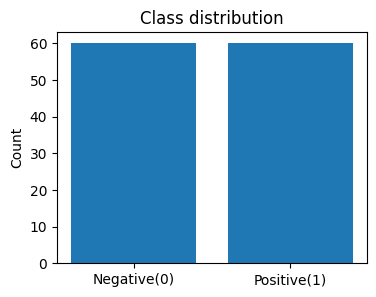

In [5]:
# Plot class distribution
counts = df["y"].value_counts().sort_index()
plt.figure(figsize=(4,3))
plt.bar(["Negative(0)", "Positive(1)"], counts.values)
plt.title("Class distribution")
plt.ylabel("Count")
plt.show()

## Missing check

In [6]:
df["_image_fullpath"] = df["ImageName"].astype(str).apply(lambda x: str(IMG_DIR / x))

missing = df[~df["_image_fullpath"].apply(lambda p: Path(p).exists())]
print("Missing images:", len(missing))

if len(missing) > 0:
    display(missing[["ImageName", "_image_fullpath"]].head(20))

Missing images: 0


## Checks (duplicates, patient_id distribution)

If multiple images belong to the same patient_id, best practice is patient-level split (to prevent leakage)

In [7]:
print("Duplicate ImageName rows:", df["ImageName"].duplicated().sum())

if "patient_id" in df.columns:
    print("Unique patient_id:", df["patient_id"].nunique())
    print("Max images per patient_id:", df["patient_id"].value_counts().max())
    display(df["patient_id"].value_counts().head(5))

Duplicate ImageName rows: 0
Unique patient_id: 120
Max images per patient_id: 1


patient_id
180      1
12334    1
11778    1
12725    1
11364    1
Name: count, dtype: int64

## Feature preprocessing (symptoms) + prevalence plot

In [8]:
# Define symptom feature columns
SYMPTOM_COLS = [
    "Hoarseness",
    "Rhinorrhea",
    "sorethroat",
    "Congestion",
    "Knownrecentcontact",
    "Headache",
    "Fever"
]

print("Symptom columns:", SYMPTOM_COLS)

Symptom columns: ['Hoarseness', 'Rhinorrhea', 'sorethroat', 'Congestion', 'Knownrecentcontact', 'Headache', 'Fever']


In [9]:
X_sym = df[SYMPTOM_COLS].copy()

# Ensure numeric; fill missing with 0 (works for binary symptoms)
for c in SYMPTOM_COLS:
    X_sym[c] = pd.to_numeric(X_sym[c], errors="coerce")
X_sym = X_sym.fillna(0.0).astype("float32")

print("Symptoms matrix shape:", X_sym.shape)
display(X_sym.head(5))

Symptoms matrix shape: (120, 7)


,Hoarseness,Rhinorrhea,sorethroat,Congestion,Knownrecentcontact,Headache,Fever
0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0


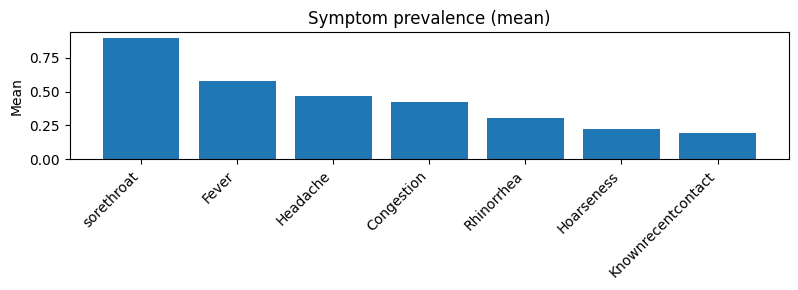

sorethroat            0.891667
Fever                 0.575000
Headache              0.466667
Congestion            0.425000
Rhinorrhea            0.308333
Hoarseness            0.225000
Knownrecentcontact    0.191667
dtype: float32

In [10]:
# Symptom prevalence overall
prevalence = X_sym.mean().sort_values(ascending=False)

plt.figure(figsize=(8,3))
plt.bar(prevalence.index, prevalence.values)
plt.title("Symptom prevalence (mean)")
plt.ylabel("Mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

display(prevalence)

In [11]:
pos_mean = X_sym[df["y"] == 1].mean()
neg_mean = X_sym[df["y"] == 0].mean()
by_label = pd.DataFrame({"Negative_mean": neg_mean, "Positive_mean": pos_mean})
by_label["Diff(Pos-Neg)"] = by_label["Positive_mean"] - by_label["Negative_mean"]

display(by_label.sort_values("Diff(Pos-Neg)", ascending=False))

,Negative_mean,Positive_mean,Diff(Pos-Neg)
sorethroat,0.866667,0.916667,0.050000
Knownrecentcontact,0.166667,0.216667,0.050000
Hoarseness,0.233333,0.216667,-0.016667
Rhinorrhea,0.350000,0.266667,-0.083333
Fever,0.616667,0.533333,-0.083333
Headache,0.533333,0.400000,-0.133333
Congestion,0.500000,0.350000,-0.150000


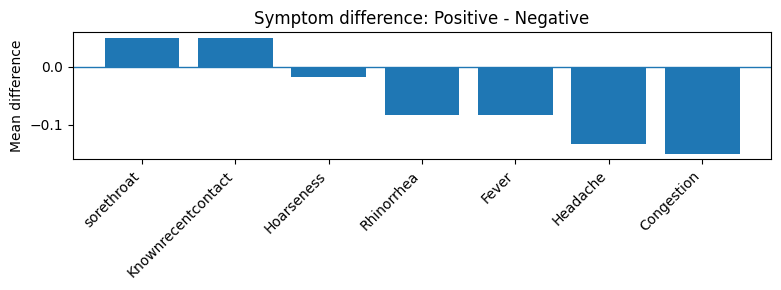

In [12]:
# Plot differences
diff = by_label["Diff(Pos-Neg)"].sort_values(ascending=False)

plt.figure(figsize=(8,3))
plt.bar(diff.index, diff.values)
plt.axhline(0, linewidth=1)
plt.title("Symptom difference: Positive - Negative")
plt.ylabel("Mean difference")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Image inspection: sizes, modes, scatter plot

In [13]:
sizes = []
modes = []

for p in df["_image_fullpath"]:
    im = Image.open(p)
    sizes.append(im.size)
    modes.append(im.mode)

sizes = np.array(sizes)

print("Images inspected:", len(sizes))
print("Unique modes:", sorted(set(modes)))

print("Width  min/mean/max:", sizes[:,0].min(), sizes[:,0].mean(), sizes[:,0].max())
print("Height min/mean/max:", sizes[:,1].min(), sizes[:,1].mean(), sizes[:,1].max())

Images inspected: 120
Unique modes: ['RGB']
Width  min/mean/max: 168 568.3666666666667 980
Height min/mean/max: 168 568.3666666666667 980


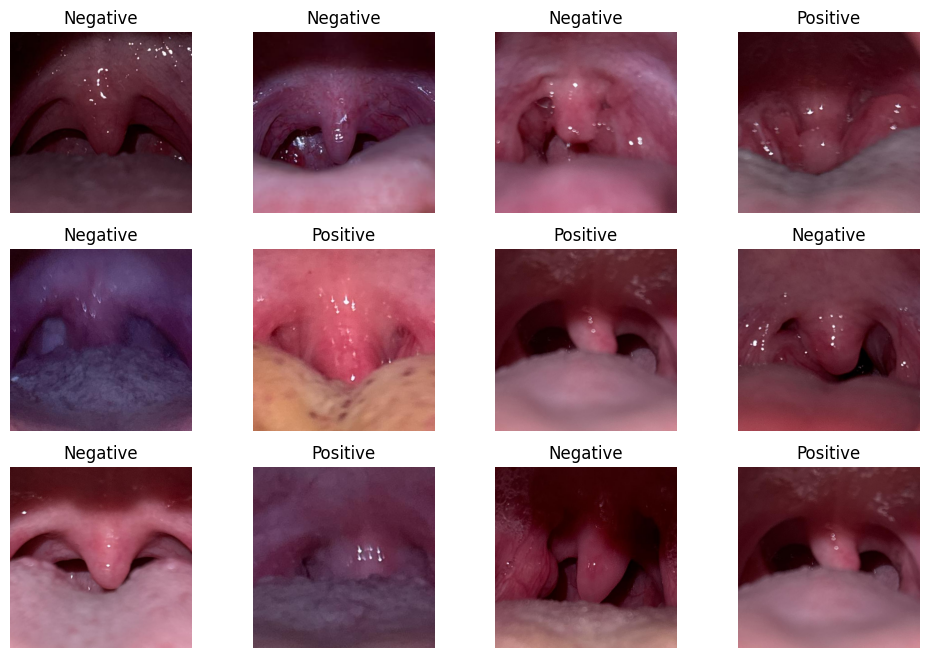

In [14]:
import random

plt.figure(figsize=(12,8))

for i in range(12):

    idx = random.randint(0,len(df)-1)

    img = Image.open(df["_image_fullpath"][idx])
    label = df["label"][idx]

    plt.subplot(3,4,i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.show()

# End To End Automated Training Using MLOps

# MLOps Weight and biases, baysian sweep end to end automation

In [ ]:
# ============================================================
#MLOps end to end automated training from preprocessing


# - Held-out TEST split (stratified)
# - 5-fold CV on train-pool only
# - Logs ONLY CV-MEAN curves + CV-MEAN final metrics + FINAL TEST metrics
# - Models (ALL multimodal):
#     1) FUSION_RESNET_GATED (resnet18/resnet50)
#     2) FUSION_RESNET_PERFORATED (your dendritic idea; 2-phase training)
#     3) FUSION_VIT_GATED (vit_b_16)

# - W&B Bayesian sweep included
# - Produces professional plots:
#     cv_mean_loss.png, cv_mean_accuracy.png, cv_mean_precision.png
# - Reproducible + documented
#
# HOW TO RUN:
#   1) pip install wandb torch torchvision scikit-learn pillow matplotlib pandas numpy
#   2) wandb login
#   3) Edit CSV_PATH and IMG_DIR below
#   4) Run this cell. It will start a W&B Bayesian sweep.

# NOTES:
# - CSV must include columns: ImageName, label, and symptom columns.
# - label values assumed: "Positive"/"Negative" (edit mapping if needed).

# ============================================================

import os, random
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
import torchvision.models as tvm

from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, confusion_matrix,
    roc_auc_score, average_precision_score
)

import wandb

# =========================
# USER CONFIG (EDIT)
# =========================
CSV_PATH = Path(r"C:/Users/madi-admin/notebooks/Training/Task-image-clinical/data/dataset_120.csv") # adjust it
IMG_DIR  = Path(r"C:/Users/madi-admin/notebooks/Training/Task-image-clinical/data") #adjust it

LABEL_COL = "label"         # expects "Positive"/"Negative"
IMAGE_COL = "ImageName"
SYMPTOM_COLS = ["Hoarseness","Rhinorrhea","sorethroat","Congestion","Knownrecentcontact","Headache","Fever"]
LABEL_MAP = {"Negative": 0, "Positive": 1}

# =========================
# GLOBALS
# =========================
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

# =========================================================
# Dataset (torchvision transforms)
# =========================================================
class StrepDatasetTV(Dataset):
    def __init__(self, df, img_dir, symptom_cols, transform):
        self.df = df.reset_index(drop=True).copy()
        self.img_dir = Path(img_dir)
        self.symptom_cols = symptom_cols
        self.transform = transform

        X = self.df[self.symptom_cols].copy()
        for c in self.symptom_cols:
            X[c] = pd.to_numeric(X[c], errors="coerce")
        X = X.fillna(0.0).astype("float32").values
        self.X = X
        self.y = self.df["y"].astype(int).values

    def __len__(self):
        return len(self.df)

    def _resolve_img_path(self, fname):
        fname = str(fname).strip()
        p = self.img_dir / fname
        if p.exists():
            return p
        return self.img_dir / Path(fname).name

    def __getitem__(self, idx):
        y = torch.tensor(int(self.y[idx]), dtype=torch.float32)
        x_sym = torch.tensor(self.X[idx], dtype=torch.float32)

        fname = self.df.loc[idx, IMAGE_COL]
        p = self._resolve_img_path(fname)
        if not p.exists():
            raise FileNotFoundError(
                f"Image not found: {fname} -> tried {p}\n"
                f"Tip: confirm IMAGE_COL='{IMAGE_COL}' and IMG_DIR='{self.img_dir}'"
            )

        img = Image.open(p).convert("RGB")
        x_img = self.transform(img)

        return {"x_img": x_img, "x_sym": x_sym, "y": y}

# =========================================================
# Models
# =========================================================
class FusionResNet_Gated(nn.Module):
    def __init__(self, symptom_dim, backbone="resnet50", dropout=0.3):
        super().__init__()
        if backbone == "resnet18":
            self.cnn = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
        elif backbone == "resnet50":
            self.cnn = tvm.resnet50(weights=tvm.ResNet50_Weights.DEFAULT)
        else:
            raise ValueError("backbone must be resnet18 or resnet50")

        img_dim = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        self.sym = nn.Sequential(
            nn.Linear(symptom_dim, 64), nn.ReLU(),
            nn.Linear(64, 64), nn.ReLU()
        )

        self.gate = nn.Sequential(
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, img_dim), nn.Sigmoid()
        )

        self.head = nn.Sequential(
            nn.Linear(img_dim + 64, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x_img, x_sym):
        img_feat = self.cnn(x_img)
        sym_feat = self.sym(x_sym)
        g = self.gate(sym_feat)
        img_mod = img_feat * g
        fused = torch.cat([img_mod, sym_feat], dim=1)
        return self.head(fused).squeeze(1)

class FusionResNet_FiLM(nn.Module):
    def __init__(self, symptom_dim, backbone="resnet50", dropout=0.3):
        super().__init__()
        if backbone == "resnet18":
            self.cnn = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
        elif backbone == "resnet50":
            self.cnn = tvm.resnet50(weights=tvm.ResNet50_Weights.DEFAULT)
        else:
            raise ValueError("backbone must be resnet18 or resnet50")

        img_dim = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        self.sym = nn.Sequential(
            nn.Linear(symptom_dim, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU()
        )

        self.gamma = nn.Linear(128, img_dim)
        self.beta  = nn.Linear(128, img_dim)

        self.head = nn.Sequential(
            nn.Linear(img_dim + 128, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x_img, x_sym):
        img_feat = self.cnn(x_img)
        sym_feat = self.sym(x_sym)
        gamma = torch.sigmoid(self.gamma(sym_feat))
        beta  = self.beta(sym_feat)
        img_mod = gamma * img_feat + beta
        fused = torch.cat([img_mod, sym_feat], dim=1)
        return self.head(fused).squeeze(1)

class DendriteLayer(nn.Module):
    def __init__(self, width, ratio=0.25):
        super().__init__()
        d_units = max(1, int(width * ratio))
        self.to_d = nn.Linear(width, d_units, bias=False)
        self.to_out = nn.Linear(d_units, width, bias=False)
        nn.init.xavier_uniform_(self.to_d.weight)
        nn.init.xavier_uniform_(self.to_out.weight)

    def forward(self, h_detached):
        d = torch.tanh(self.to_d(h_detached))
        return self.to_out(d)

class FusionResNet_Perforated(nn.Module):
    def __init__(self, symptom_dim, backbone="resnet50", dropout=0.3, fusion_h=256, use_dendrites=False):
        super().__init__()
        self.use_dendrites = use_dendrites

        if backbone == "resnet18":
            self.cnn = tvm.resnet18(weights=tvm.ResNet18_Weights.DEFAULT)
        elif backbone == "resnet50":
            self.cnn = tvm.resnet50(weights=tvm.ResNet50_Weights.DEFAULT)
        else:
            raise ValueError("backbone must be resnet18 or resnet50")

        img_dim = self.cnn.fc.in_features
        self.cnn.fc = nn.Identity()

        self.sym = nn.Sequential(
            nn.Linear(symptom_dim, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU()
        )

        self.fc1 = nn.Linear(img_dim + 128, fusion_h)
        self.fc2 = nn.Linear(fusion_h, fusion_h)
        self.out = nn.Linear(fusion_h, 1)
        self.drop = nn.Dropout(dropout)

        self.dend1 = DendriteLayer(fusion_h)
        self.dend2 = DendriteLayer(fusion_h)

    def forward(self, x_img, x_sym):
        img_feat = self.cnn(x_img)
        sym_feat = self.sym(x_sym)
        z = torch.cat([img_feat, sym_feat], dim=1)

        h1 = F.relu(self.fc1(z))
        if self.use_dendrites:
            h1 = h1 + self.dend1(h1.detach())
        h1 = self.drop(h1)

        h2 = F.relu(self.fc2(h1))
        if self.use_dendrites:
            h2 = h2 + self.dend2(h2.detach())
        h2 = self.drop(h2)

        return self.out(h2).squeeze(1)

    def freeze_backbone_params(self):
        for p in list(self.cnn.parameters()) + list(self.sym.parameters()) + \
                 list(self.fc1.parameters()) + list(self.fc2.parameters()) + list(self.out.parameters()):
            p.requires_grad = False

    def dendrite_parameters(self):
        return list(self.dend1.parameters()) + list(self.dend2.parameters())

# =========================================================
# Early stopping
# =========================================================
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0, mode="min"):
        assert mode in ["min","max"]
        self.patience = int(patience)
        self.min_delta = float(min_delta)
        self.mode = mode
        self.best = None
        self.bad = 0
        self.best_state = None

    def _improved(self, val):
        if self.best is None:
            return True
        if self.mode == "min":
            return val < (self.best - self.min_delta)
        return val > (self.best + self.min_delta)

    def step(self, val, model):
        val = float(val)
        if self._improved(val):
            self.best = val
            self.bad = 0
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.bad += 1
        return self.bad >= self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state, strict=True)

# =========================================================
# Optimizer selection (multi-optimizer)
# =========================================================
def select_optimizer(cfg, params):
    lr = float(cfg.learning_rate)
    wd = float(getattr(cfg, "weight_decay", 0.0))
    opt = str(cfg.optimizer)

    if opt == "Adam":
        return optim.Adam(params, lr=lr, weight_decay=wd)
    elif opt == "AdamW":
        return optim.AdamW(params, lr=lr, weight_decay=wd)
    elif opt == "SGD":
        return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=wd, nesterov=True)
    elif opt == "RMSprop":
        return optim.RMSprop(params, lr=lr, momentum=0.9, weight_decay=wd)
    else:
        raise ValueError(f"Invalid optimizer choice: {opt}")

# =========================================================
# Metrics / Loss
# =========================================================
def make_pos_weight(df_train):
    n_pos = int(df_train["y"].sum())
    n_neg = int(len(df_train) - n_pos)
    if n_pos <= 0:
        return None
    return torch.tensor([n_neg / max(1, n_pos)], device=DEVICE, dtype=torch.float32)

def bce_with_logits(logits, y, pos_weight=None):
    if pos_weight is None:
        return nn.BCEWithLogitsLoss()(logits, y)
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight)(logits, y)

@torch.no_grad()
def evaluate(model, loader, pos_weight=None):
    model.eval()
    losses = []
    y_true, y_prob = [], []

    for batch in loader:
        x_img = batch["x_img"].to(DEVICE)
        x_sym = batch["x_sym"].to(DEVICE)
        y = batch["y"].to(DEVICE)

        logits = model(x_img, x_sym)
        loss = bce_with_logits(logits, y, pos_weight=pos_weight)
        losses.append(float(loss.item()))

        prob = torch.sigmoid(logits).detach().cpu().numpy()
        y_prob.append(prob)
        y_true.append(batch["y"].cpu().numpy().astype(int))

    y_true = np.concatenate(y_true) if len(y_true) else np.array([])
    y_prob = np.concatenate(y_prob) if len(y_prob) else np.array([])
    y_pred = (y_prob >= 0.5).astype(int) if len(y_prob) else np.array([])

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    spec = float(tn / (tn + fp)) if (tn + fp) > 0 else 0.0

    auroc = np.nan
    auprc = np.nan
    if len(np.unique(y_true)) == 2:
        auroc = float(roc_auc_score(y_true, y_prob))
        auprc = float(average_precision_score(y_true, y_prob))

    return {
        "loss": float(np.mean(losses)) if losses else np.nan,
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "specificity": float(spec),
        "auroc": auroc,
        "auprc": auprc,
        "tp": float(tp), "fp": float(fp), "tn": float(tn), "fn": float(fn)
    }

def train_one_epoch(model, loader, optimizer, pos_weight=None):
    model.train()
    losses = []
    for batch in loader:
        x_img = batch["x_img"].to(DEVICE)
        x_sym = batch["x_sym"].to(DEVICE)
        y = batch["y"].to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x_img, x_sym)
        loss = bce_with_logits(logits, y, pos_weight=pos_weight)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.item()))
    return float(np.mean(losses)) if losses else np.nan

# =========================================================
# Mean CV curve plotting (mean±std over folds)
# =========================================================
def plot_cv_mean(curves_train, curves_val, title, ylabel, outpath):
    K = len(curves_train)
    max_len = max(len(x) for x in curves_train) if K else 0
    A = np.full((K, max_len), np.nan, dtype=float)
    B = np.full((K, max_len), np.nan, dtype=float)
    for i in range(K):
        A[i, :len(curves_train[i])] = curves_train[i]
        B[i, :len(curves_val[i])] = curves_val[i]

    x = np.arange(1, max_len + 1)
    muA, sdA = np.nanmean(A, axis=0), np.nanstd(A, axis=0)
    muB, sdB = np.nanmean(B, axis=0), np.nanstd(B, axis=0)

    plt.figure(figsize=(7,4))
    plt.plot(x, muA, label="Train")
    plt.fill_between(x, muA - sdA, muA + sdA, alpha=0.2)
    plt.plot(x, muB, label="Validation")
    plt.fill_between(x, muB - sdB, muB + sdB, alpha=0.2)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(outpath, dpi=200)
    plt.close()

# =========================================================
# Torchvision augmentation (professional + conservative)
# =========================================================
def build_transforms(cfg):
    img_size = int(cfg.img_size)
    MEAN = [0.485, 0.456, 0.406]
    STD  = [0.229, 0.224, 0.225]

    train_tfms = T.Compose([
        T.RandomResizedCrop(img_size, scale=(0.90, 1.00), ratio=(0.95, 1.05)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomRotation(degrees=12),
        T.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.05, hue=0.02),
        T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])

    val_tfms = T.Compose([
        T.Resize((img_size, img_size)),
        T.ToTensor(),
        T.Normalize(MEAN, STD),
    ])
    return train_tfms, val_tfms

# =========================================================
# Model builder
# =========================================================
def build_model(cfg, symptom_dim, use_dendrites=False):
    mt = str(cfg.model_type)
    bb = str(cfg.cnn_backbone)

    if mt == "FUSION_RESNET_GATED":
        return FusionResNet_Gated(symptom_dim, backbone=bb, dropout=float(cfg.dropout))
    if mt == "FUSION_RESNET_FILM":
        return FusionResNet_FiLM(symptom_dim, backbone=bb, dropout=float(cfg.dropout))
    if mt == "FUSION_RESNET_PERFORATED":
        return FusionResNet_Perforated(
            symptom_dim, backbone=bb, dropout=float(cfg.dropout),
            fusion_h=int(cfg.fusion_h), use_dendrites=use_dendrites
        )
    raise ValueError(f"Unknown model_type: {mt}")

def train_perforated_two_phase(cfg, symptom_dim, dl_tr, dl_va, pos_weight):
    # Phase 1 backbone (no dendrites)
    base = build_model(cfg, symptom_dim, use_dendrites=False).to(DEVICE)
    opt = select_optimizer(cfg, base.parameters())
    es = EarlyStopping(patience=int(cfg.patience), min_delta=float(cfg.min_delta), mode="min")

    tr_loss_hist, va_loss_hist = [], []
    tr_acc_hist,  va_acc_hist  = [], []
    tr_prec_hist, va_prec_hist = [], []
    tr_rec_hist,  va_rec_hist  = [], []

    epochs_base = int(cfg.epochs_base)
    epochs_total = int(cfg.epochs)

    for _ in range(min(epochs_base, epochs_total)):
        tr_loss = train_one_epoch(base, dl_tr, opt, pos_weight=pos_weight)
        tr_m = evaluate(base, dl_tr, pos_weight=pos_weight)
        va_m = evaluate(base, dl_va, pos_weight=pos_weight)

        tr_loss_hist.append(tr_loss);           va_loss_hist.append(va_m["loss"])
        tr_acc_hist.append(tr_m["accuracy"]);   va_acc_hist.append(va_m["accuracy"])
        tr_prec_hist.append(tr_m["precision"]); va_prec_hist.append(va_m["precision"])
        tr_rec_hist.append(tr_m["recall"]);     va_rec_hist.append(va_m["recall"])

        if es.step(va_m["loss"], base):
            break
    es.restore_best(base)

    # Phase 2 dendrites only
    perf = build_model(cfg, symptom_dim, use_dendrites=True).to(DEVICE)
    perf.load_state_dict(base.state_dict(), strict=True)
    perf.freeze_backbone_params()
    opt_d = select_optimizer(cfg, perf.dendrite_parameters())

    es2 = EarlyStopping(patience=int(cfg.patience), min_delta=float(cfg.min_delta), mode="min")
    epochs_dend = int(cfg.epochs_dend)

    for _ in range(min(epochs_dend, max(1, epochs_total - len(tr_loss_hist)))):
        perf.train()
        batch_losses = []
        for batch in dl_tr:
            x_img = batch["x_img"].to(DEVICE)
            x_sym = batch["x_sym"].to(DEVICE)
            y = batch["y"].to(DEVICE)

            opt_d.zero_grad(set_to_none=True)
            logits = perf(x_img, x_sym)
            loss = bce_with_logits(logits, y, pos_weight=pos_weight)
            loss.backward()
            opt_d.step()
            batch_losses.append(float(loss.item()))
        tr_loss = float(np.mean(batch_losses)) if batch_losses else np.nan

        tr_m = evaluate(perf, dl_tr, pos_weight=pos_weight)
        va_m = evaluate(perf, dl_va, pos_weight=pos_weight)

        tr_loss_hist.append(tr_loss);           va_loss_hist.append(va_m["loss"])
        tr_acc_hist.append(tr_m["accuracy"]);   va_acc_hist.append(va_m["accuracy"])
        tr_prec_hist.append(tr_m["precision"]); va_prec_hist.append(va_m["precision"])
        tr_rec_hist.append(tr_m["recall"]);     va_rec_hist.append(va_m["recall"])

        if es2.step(va_m["loss"], perf):
            break
    es2.restore_best(perf)

    return perf, (tr_loss_hist, va_loss_hist, tr_acc_hist, va_acc_hist, tr_prec_hist, va_prec_hist, tr_rec_hist, va_rec_hist)

# =========================================================
# W&B train() with mean CV metrics only
# =========================================================
def train():
    seed_everything(SEED)
    run = wandb.init()
    cfg = run.config

    # ---- load + validate
    df = pd.read_csv(CSV_PATH).copy()
    required_cols = [LABEL_COL, IMAGE_COL] + SYMPTOM_COLS
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"CSV is missing required columns: {missing}\nAvailable columns: {list(df.columns)}")

    df["y"] = df[LABEL_COL].map(LABEL_MAP)
    if df["y"].isna().any():
        bad = df[df["y"].isna()][LABEL_COL].unique()
        raise ValueError(f"Unmapped labels in {LABEL_COL}: {bad}. Expected keys: {list(LABEL_MAP.keys())}")
    df["y"] = df["y"].astype(int)

    # ---- held-out TEST split
    splitter = StratifiedShuffleSplit(n_splits=1, test_size=float(cfg.test_size), random_state=SEED)
    idx_train, idx_test = next(splitter.split(df, df["y"]))
    df_train_pool = df.iloc[idx_train].reset_index(drop=True)
    df_test = df.iloc[idx_test].reset_index(drop=True)

    symptom_dim = len(SYMPTOM_COLS)
    pos_weight = make_pos_weight(df_train_pool) if bool(cfg.use_pos_weight) else None

    train_tfms, val_tfms = build_transforms(cfg)

    # ---- CV on train pool
    num_folds = int(cfg.num_folds)
    batch_size = int(cfg.batch_size)
    kf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=SEED)

    fold_val_loss, fold_val_acc, fold_val_prec, fold_val_rec = [], [], [], []

    curves_tr_loss, curves_va_loss = [], []
    curves_tr_acc,  curves_va_acc  = [], []
    curves_tr_prec, curves_va_prec = [], []
    curves_tr_rec,  curves_va_rec  = [], []

    for _, (tr_idx, va_idx) in enumerate(kf.split(df_train_pool, df_train_pool["y"]), 1):
        dtr = df_train_pool.iloc[tr_idx].reset_index(drop=True)
        dva = df_train_pool.iloc[va_idx].reset_index(drop=True)

        ds_tr = StrepDatasetTV(dtr, IMG_DIR, SYMPTOM_COLS, train_tfms)
        ds_va = StrepDatasetTV(dva, IMG_DIR, SYMPTOM_COLS, val_tfms)

        dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, num_workers=0)
        dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False, num_workers=0)

        mt = str(cfg.model_type)

        if mt == "FUSION_RESNET_PERFORATED":
            model, hists = train_perforated_two_phase(cfg, symptom_dim, dl_tr, dl_va, pos_weight)
            tr_loss_hist, va_loss_hist, tr_acc_hist, va_acc_hist, tr_prec_hist, va_prec_hist, tr_rec_hist, va_rec_hist = hists
        else:
            model = build_model(cfg, symptom_dim, use_dendrites=False).to(DEVICE)
            opt = select_optimizer(cfg, model.parameters())
            es = EarlyStopping(patience=int(cfg.patience), min_delta=float(cfg.min_delta), mode="min")

            tr_loss_hist, va_loss_hist = [], []
            tr_acc_hist,  va_acc_hist  = [], []
            tr_prec_hist, va_prec_hist = [], []
            tr_rec_hist,  va_rec_hist  = [], []

            for _ in range(int(cfg.epochs)):
                tr_loss = train_one_epoch(model, dl_tr, opt, pos_weight=pos_weight)
                tr_m = evaluate(model, dl_tr, pos_weight=pos_weight)
                va_m = evaluate(model, dl_va, pos_weight=pos_weight)

                tr_loss_hist.append(tr_loss);           va_loss_hist.append(va_m["loss"])
                tr_acc_hist.append(tr_m["accuracy"]);   va_acc_hist.append(va_m["accuracy"])
                tr_prec_hist.append(tr_m["precision"]); va_prec_hist.append(va_m["precision"])
                tr_rec_hist.append(tr_m["recall"]);     va_rec_hist.append(va_m["recall"])

                if es.step(va_m["loss"], model):
                    break
            es.restore_best(model)

        va_best = evaluate(model, dl_va, pos_weight=pos_weight)
        fold_val_loss.append(va_best["loss"])
        fold_val_acc.append(va_best["accuracy"])
        fold_val_prec.append(va_best["precision"])
        fold_val_rec.append(va_best["recall"])

        curves_tr_loss.append(tr_loss_hist); curves_va_loss.append(va_loss_hist)
        curves_tr_acc.append(tr_acc_hist);   curves_va_acc.append(va_acc_hist)
        curves_tr_prec.append(tr_prec_hist); curves_va_prec.append(va_prec_hist)
        curves_tr_rec.append(tr_rec_hist);   curves_va_rec.append(va_rec_hist)

    # ---- CV mean metrics (ONLY)
    cv_mean_val_loss   = float(np.mean(fold_val_loss))
    cv_mean_val_acc    = float(np.mean(fold_val_acc))
    cv_precision_mean  = float(np.mean(fold_val_prec))
    cv_recall_mean     = float(np.mean(fold_val_rec))

    # ---- mean±std CV curves
    os.makedirs("plots", exist_ok=True)
    plot_cv_mean(curves_tr_loss, curves_va_loss, "Mean CV Loss (Train vs Val)", "BCEWithLogitsLoss", "plots/cv_mean_loss.png")
    plot_cv_mean(curves_tr_acc,  curves_va_acc,  "Mean CV Accuracy (Train vs Val)", "Accuracy", "plots/cv_mean_accuracy.png")
    plot_cv_mean(curves_tr_prec, curves_va_prec, "Mean CV Precision (Train vs Val)", "Precision", "plots/cv_mean_precision.png")
    plot_cv_mean(curves_tr_rec,  curves_va_rec,  "Mean CV Recall (Train vs Val)", "Recall", "plots/cv_mean_recall.png")

    wandb.log({
        "cv_mean/val_loss": cv_mean_val_loss,
        "cv_mean/val_accuracy": cv_mean_val_acc,
        "cv_precision_mean": cv_precision_mean,
        "cv_recall_mean": cv_recall_mean,

        "plots/cv_mean_loss": wandb.Image("plots/cv_mean_loss.png"),
        "plots/cv_mean_accuracy": wandb.Image("plots/cv_mean_accuracy.png"),
        "plots/cv_mean_precision": wandb.Image("plots/cv_mean_precision.png"),
        "plots/cv_mean_recall": wandb.Image("plots/cv_mean_recall.png"),
    })

    # ---- Final train (train_pool -> internal val), then TEST
    splitter2 = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
    idx_tr2, idx_va2 = next(splitter2.split(df_train_pool, df_train_pool["y"]))
    df_tr_final = df_train_pool.iloc[idx_tr2].reset_index(drop=True)
    df_va_final = df_train_pool.iloc[idx_va2].reset_index(drop=True)

    dl_tr_final = DataLoader(StrepDatasetTV(df_tr_final, IMG_DIR, SYMPTOM_COLS, train_tfms),
                             batch_size=batch_size, shuffle=True, num_workers=0)
    dl_va_final = DataLoader(StrepDatasetTV(df_va_final, IMG_DIR, SYMPTOM_COLS, val_tfms),
                             batch_size=batch_size, shuffle=False, num_workers=0)
    dl_test = DataLoader(StrepDatasetTV(df_test, IMG_DIR, SYMPTOM_COLS, val_tfms),
                         batch_size=batch_size, shuffle=False, num_workers=0)

    mt = str(cfg.model_type)
    if mt == "FUSION_RESNET_PERFORATED":
        model, _ = train_perforated_two_phase(cfg, symptom_dim, dl_tr_final, dl_va_final, pos_weight)
    else:
        model = build_model(cfg, symptom_dim, use_dendrites=False).to(DEVICE)
        opt = select_optimizer(cfg, model.parameters())
        es_final = EarlyStopping(patience=int(cfg.patience), min_delta=float(cfg.min_delta), mode="min")

        for _ in range(int(cfg.epochs)):
            _ = train_one_epoch(model, dl_tr_final, opt, pos_weight=pos_weight)
            va_m = evaluate(model, dl_va_final, pos_weight=pos_weight)
            if es_final.step(va_m["loss"], model):
                break
        es_final.restore_best(model)

    test_m = evaluate(model, dl_test, pos_weight=pos_weight)
    wandb.log({
        "test/loss": test_m["loss"],
        "test/accuracy": test_m["accuracy"],
        "test/precision": test_m["precision"],
        "test/recall": test_m["recall"],
        "test/specificity": test_m["specificity"],
        "test/auroc": test_m["auroc"],
        "test/auprc": test_m["auprc"],
    })

    print("\n=== SUMMARY ===")
    print(f"Run: {run.name} | model: {mt} | optimizer: {cfg.optimizer}")
    print(
        f"CV mean val_acc: {cv_mean_val_acc:.4f} | CV mean val_loss: {cv_mean_val_loss:.4f} | "
        f"CV mean precision: {cv_precision_mean:.4f} | CV mean recall: {cv_recall_mean:.4f}"
    )
    print(
        f"TEST acc: {test_m['accuracy']:.4f} | TEST precision: {test_m['precision']:.4f} | "
        f"TEST recall: {test_m['recall']:.4f} | TEST AUROC: {test_m['auroc']}"
    )

# =========================================================
# Bayesian sweep config 
# =========================================================
sweep_config = {
    "method": "bayes",
    "metric": {"name": "cv_precision_mean", "goal": "maximize"},
    "parameters": {
        "test_size": {"value": 0.20},
        "num_folds": {"value": 5},
        "img_size": {"value": 224},

        "epochs": {"values": [100, 250]},
        "batch_size": {"values": [8, 16]},

        "optimizer": {"values": ["AdamW", "Adam", "SGD", "RMSprop"]},

        "learning_rate": {"distribution": "log_uniform_values", "min": 1e-5, "max": 5e-4},
        "weight_decay": {"distribution": "log_uniform_values", "min": 1e-6, "max": 1e-3},
        "dropout": {"distribution": "q_uniform", "min": 0.10, "max": 0.75, "q": 0.05},

        "use_pos_weight": {"values": [True, False]},
        "patience": {"values": [5, 7]},
        "min_delta": {"values": [0.0, 1e-4]},

        "model_type": {"values": [
            "FUSION_RESNET_GATED",
            "FUSION_RESNET_FILM",
            "FUSION_RESNET_PERFORATED",
        ]},
        "cnn_backbone": {"values": ["resnet50", "resnet18"]},

        "fusion_h": {"values": [128, 256]},
        "epochs_base": {"values": [10, 12, 15]},
        "epochs_dend": {"values": [6, 8, 10]},
    }
}

PROJECT = "Madi-strep-multimodal-wandb"
sweep_id = wandb.sweep(sweep_config, project=PROJECT)


wandb.agent(sweep_id, function=train, count=150)

Create sweep with ID: 7ykbi0q0
Sweep URL: https://wandb.ai/madi22/Madi-strep-multimodal-wandb/sweeps/7ykbi0q0


wandb: Agent Starting Run: i2au72m4 with config:
wandb: 	batch_size: 8
wandb: 	cnn_backbone: resnet50
wandb: 	dropout: 0.75
wandb: 	epochs: 100
wandb: 	epochs_base: 10
wandb: 	epochs_dend: 10
wandb: 	fusion_h: 256
wandb: 	img_size: 224
wandb: 	learning_rate: 4.072894011118893e-05
wandb: 	min_delta: 0
wandb: 	model_type: FUSION_RESNET_GATED
wandb: 	num_folds: 5
wandb: 	optimizer: Adam
wandb: 	patience: 5
wandb: 	test_size: 0.2
wandb: 	use_pos_weight: False
wandb: 	weight_decay: 5.741363370548724e-05



=== SUMMARY ===
Run: eager-sweep-1 | model: FUSION_RESNET_GATED | optimizer: Adam
CV mean val_acc: 0.6037 | CV mean val_loss: 0.6527 | CV mean precision: 0.5291 | CV mean recall: 0.5422
TEST acc: 0.5417 | TEST precision: 0.6000 | TEST recall: 0.2500 | TEST AUROC: 0.5277777777777779


cv_mean/val_accuracy,▁
cv_mean/val_loss,▁
cv_precision_mean,▁
cv_recall_mean,▁
test/accuracy,▁
test/auprc,▁
test/auroc,▁
test/loss,▁
test/precision,▁
test/recall,▁
test/specificity,▁


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 3lq0aefl with config:
wandb: 	batch_size: 16
wandb: 	cnn_backbone: resnet18
wandb: 	dropout: 0.2
wandb: 	epochs: 100
wandb: 	epochs_base: 10
wandb: 	epochs_dend: 6
wandb: 	fusion_h: 128
wandb: 	img_size: 224
wandb: 	learning_rate: 1.6821728401121256e-05
wandb: 	min_delta: 0.0001
wandb: 	model_type: FUSION_RESNET_FILM
wandb: 	num_folds: 5
wandb: 	optimizer: SGD
wandb: 	patience: 5
wandb: 	test_size: 0.2
wandb: 	use_pos_weight: True
wandb: 	weight_decay: 0.00024371215171909035



=== SUMMARY ===
Run: fallen-sweep-2 | model: FUSION_RESNET_FILM | optimizer: SGD
CV mean val_acc: 0.5532 | CV mean val_loss: 0.6820 | CV mean precision: 0.4792 | CV mean recall: 0.5156
TEST acc: 0.4583 | TEST precision: 0.4444 | TEST recall: 0.3333 | TEST AUROC: 0.3819444444444444


cv_mean/val_accuracy,▁
cv_mean/val_loss,▁
cv_precision_mean,▁
cv_recall_mean,▁
test/accuracy,▁
test/auprc,▁
test/auroc,▁
test/loss,▁
test/precision,▁
test/recall,▁
test/specificity,▁


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: xnt714j4 with config:
wandb: 	batch_size: 16
wandb: 	cnn_backbone: resnet50
wandb: 	dropout: 0.5
wandb: 	epochs: 100
wandb: 	epochs_base: 12
wandb: 	epochs_dend: 6
wandb: 	fusion_h: 128
wandb: 	img_size: 224
wandb: 	learning_rate: 0.00017985311726679502
wandb: 	min_delta: 0.0001
wandb: 	model_type: FUSION_RESNET_PERFORATED
wandb: 	num_folds: 5
wandb: 	optimizer: RMSprop
wandb: 	patience: 5
wandb: 	test_size: 0.2
wandb: 	use_pos_weight: True
wandb: 	weight_decay: 0.0004250778336418205
